2026-03-27 14:03:06: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-03-27 14:03:06: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-03-27 14:03:06: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2026-03-27 14:03:08: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.
2026-03-27 14:03:08: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-03-27 14:03:08: oggm.cfg: PARAMS['store_fl_diagnostics'] changed from `False` to `True`.
2026-03-27 14:03:08: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2026-03-27 14:03:08: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2026-03-27 14:03:08: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-03-27 14:03:08: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in

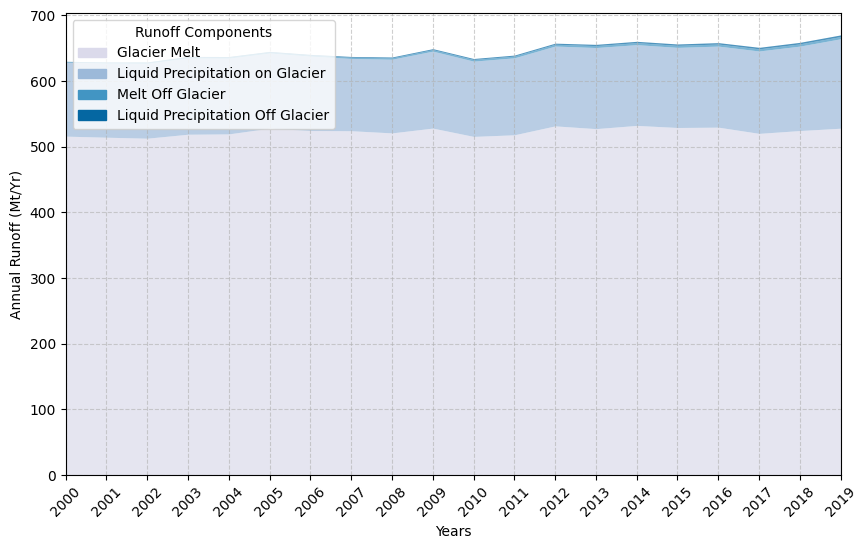

Yearly Runoff in 2000 (Megatonnes/Yr):
melt_on_glacier: 503.7774
liq_prcp_on_glacier: 113.3046
melt_off_glacier: 0.0030
liq_prcp_off_glacier: 0.0023

Total Runoff in 2000: 617.0873 Megatonnes

Yearly Runoff in 2019 (Megatonnes/Yr):
melt_on_glacier: 561.4364
liq_prcp_on_glacier: 115.9944
melt_off_glacier: 3.9015
liq_prcp_off_glacier: 2.8931

Total Runoff in 2019: 684.2253 Megatonnes


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import oggm.cfg as cfg
from oggm import utils, workflow, tasks

# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_historical_run', reset=True)
cfg.PARAMS['min_ice_thick_for_length'] = 1
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['store_fl_diagnostics'] = True  # Important for hydrological outputs

# Define the glacier ID
rgi_id = 'RGI60-06.00291'

# Get the pre-processed glacier directories
gdirs = workflow.init_glacier_directories([rgi_id], from_prepro_level=5, prepro_base_url=utils.DEFAULT_BASE_URL)



# Perform the historical run using actual climate data with hydrological outputs
workflow.execute_entity_task(
    tasks.run_with_hydro,  # This will include hydrological outputs
    gdirs,
    run_task=tasks.run_from_climate_data,  # Using actual climate data
    output_filesuffix='_historical',
    ys=2000, 
    ye=2020,
    store_monthly_hydro=True  # Store monthly hydrological outputs
)

# Load glacier dataset with hydrological diagnostics
def load_glacier_dataset(gdirs):
    with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix='_historical')) as ds:
        return ds.isel(time=slice(0, -1)).load() 

# Function to plot glacier runoff
def plot_glacier_runoff(gdirs):
    # Load results
    ds = load_glacier_dataset(gdirs)
    
    # Runoff variables to plot
    runoff_vars = ['melt_on_glacier', 'liq_prcp_on_glacier', 'melt_off_glacier', 'liq_prcp_off_glacier']

    # Extract and process runoff data
    df_annual = ds[runoff_vars].to_dataframe() * 1e-9  # Convert to megatonnes
    df_runoff = df_annual.rolling(12, center=True, min_periods=1).mean()  # Smooth data

    # Create stacked area plot
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette("PuBu", n_colors=len(runoff_vars)) 
    df_runoff.plot.area(ax=ax, color=colors, alpha=0.7, linewidth=0)

    # Set labels and x,y axis
    ax.set_xlabel('Years')
    ax.set_ylabel('Annual Runoff (Mt/Yr)')
    ax.set_xlim(2000, 2019)
    ax.set_xticks(np.arange(2000, 2020, 1))
    ax.set_xticklabels(np.arange(2000, 2020, 1).astype(int), rotation=45)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add legend manually
    legend_patches = [
        Patch(color=colors[0], label='Glacier Melt'),
        Patch(color=colors[1], label='Liquid Precipitation on Glacier'),
        Patch(color=colors[2], label='Melt Off Glacier'),
        Patch(color=colors[3], label='Liquid Precipitation Off Glacier')
    ]
    ax.legend(handles=legend_patches, title='Runoff Components', loc='upper left')
    
    # Save plots in different formats
    plt.savefig('figureout/Runoff_20002019.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_glacier_runoff(gdirs)

# Fetch runoff and their components at the initial and final years
def get_yearly_runoff(gdirs):  
    # Load results  
    with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix='_historical')) as ds:  
        historical_results = ds.isel(time=slice(0, -1)).load()  

    # Runoff variables  
    runoff_vars = ['melt_on_glacier', 'liq_prcp_on_glacier', 'melt_off_glacier', 'liq_prcp_off_glacier']  

    # Extract and process runoff data  
    df_annual = historical_results[runoff_vars].to_dataframe() * 1e-9  # Convert to megatonnes  

    # Get the initial and final years  
    initial_year = int(df_annual.index[0])  
    final_year = int(df_annual.index[-1])  

    # Print initial year runoff values  
    print(f"Yearly Runoff in {initial_year} (Megatonnes/Yr):")  
    initial_runoff_values = {}  
    for var in runoff_vars:  
        value = df_annual.loc[initial_year, var]  
        initial_runoff_values[var] = value  
        print(f"{var}: {value:.4f}")  
    total_initial_runoff = sum(initial_runoff_values.values())  
    print(f"\nTotal Runoff in {initial_year}: {total_initial_runoff:.4f} Megatonnes\n")  

    # Print final year runoff values  
    print(f"Yearly Runoff in {final_year} (Megatonnes/Yr):")  
    final_runoff_values = {}  
    for var in runoff_vars:  
        value = df_annual.loc[final_year, var]  
        final_runoff_values[var] = value  
        print(f"{var}: {value:.4f}")  
    total_final_runoff = sum(final_runoff_values.values())  
    print(f"\nTotal Runoff in {final_year}: {total_final_runoff:.4f} Megatonnes")  

# Call the function to get yearly runoff
get_yearly_runoff(gdirs)

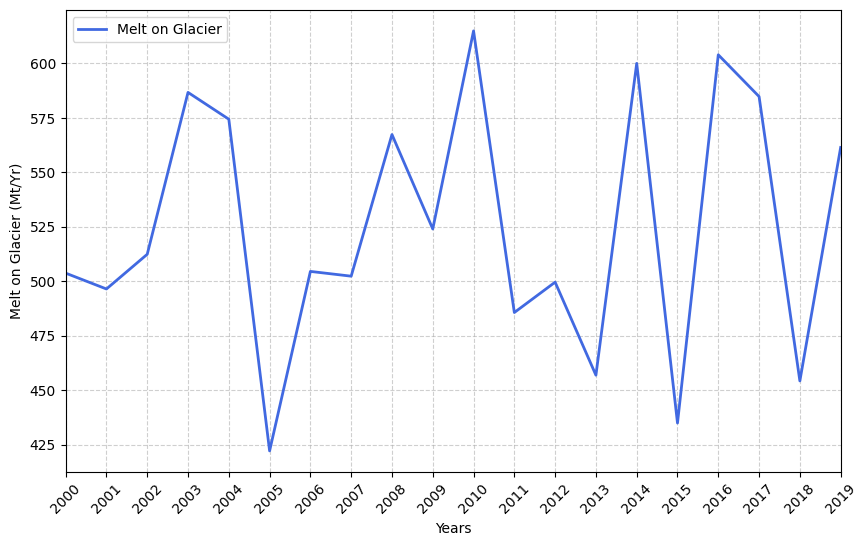

In [2]:
# Function to analyze and plot melt_on_glacier runoff (without rolling mean)
def plot_melt_on_glacier(gdirs):
    # Load the dataset
    ds = load_glacier_dataset(gdirs)
    
    # Extract and process melt_on_glacier data
    melt_on_glacier_data = ds['melt_on_glacier'].to_series() * 1e-9  # Convert to megatonnes
    
    # Create a plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(melt_on_glacier_data.index, melt_on_glacier_data.values, label='Melt on Glacier', color='royalblue', lw=2)

    # Set labels and title
    ax.set_xlabel('Years')
    ax.set_ylabel('Melt on Glacier (Mt/Yr)')
    
    # Set x-axis limits and ticks
    ax.set_xlim(2000, 2019)
    ax.set_xticks(np.arange(2000, 2020, 1))  # Set ticks for each year
    ax.set_xticklabels(np.arange(2000, 2020, 1).astype(int), rotation=45)

    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add legend 
    ax.legend(['Melt on Glacier'], loc='upper left')

    # Save and show the plot
    plt.savefig('figureout/Melt_on_Glacier_20002019.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function to plot melt on glacier runoff
plot_melt_on_glacier(gdirs)



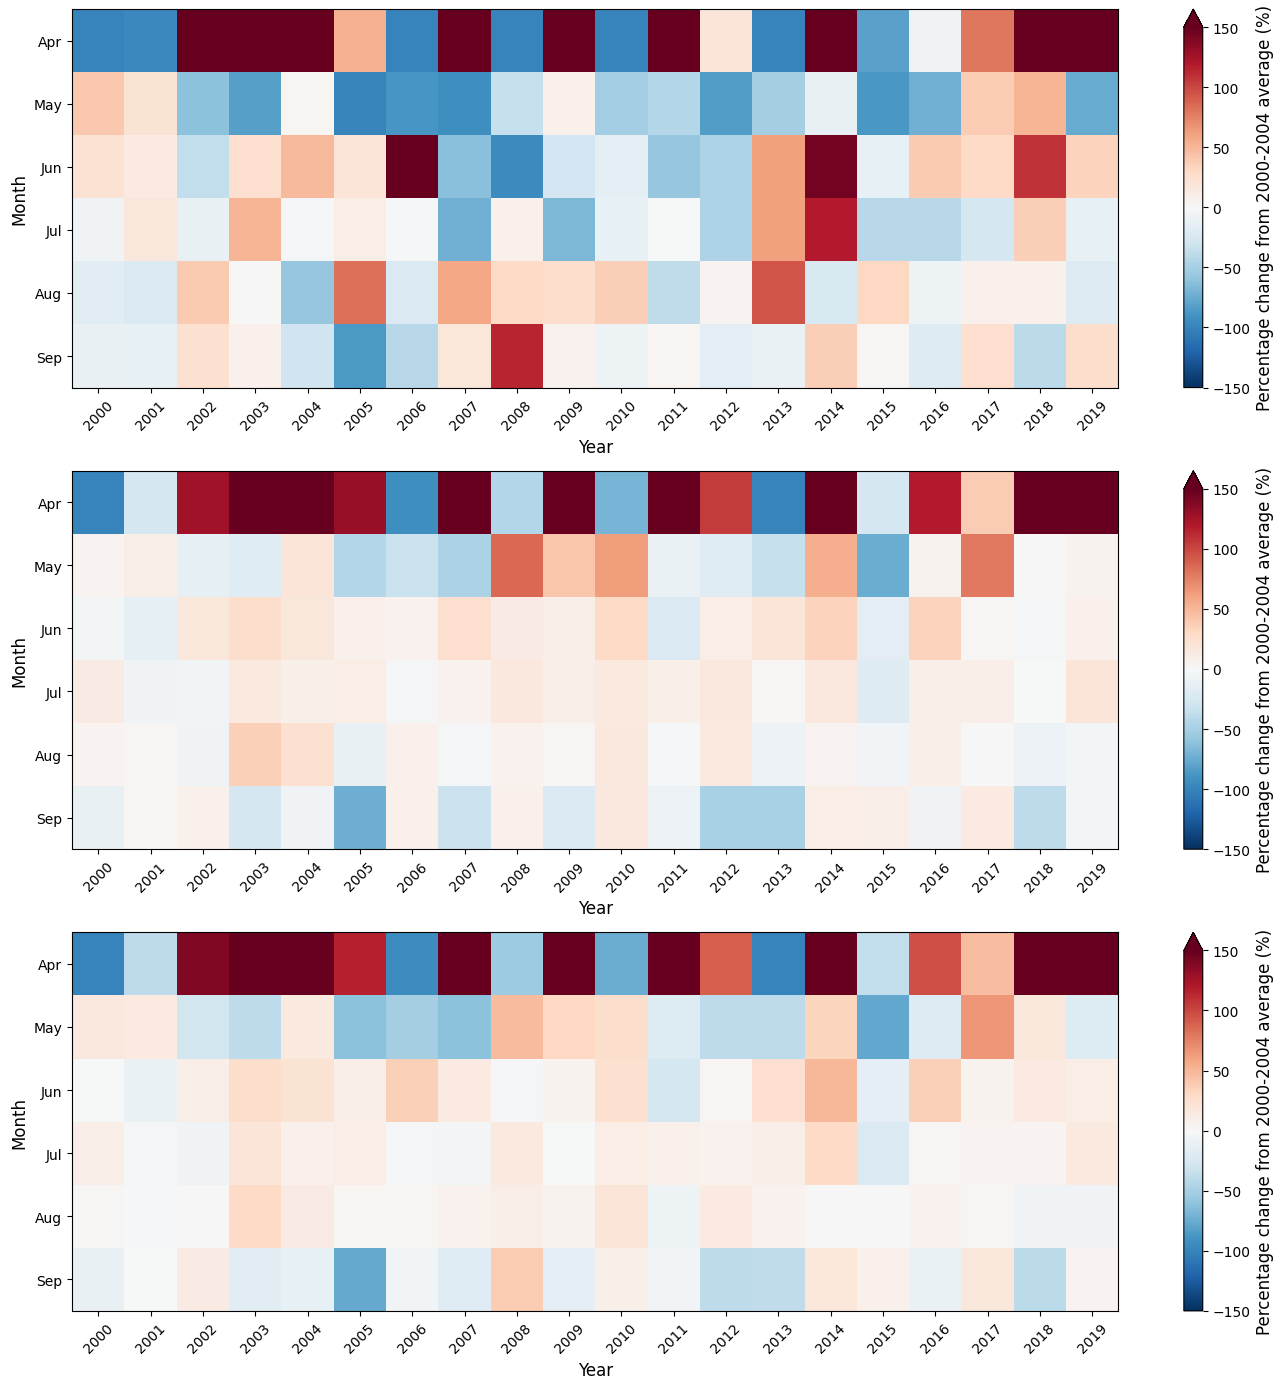

In [5]:

# Create 3 subplots (now including melt)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))  # Increased height for 3 plots

# Load the dataset
ds = load_glacier_dataset(gdirs)

def plot_april_september_change(ax, data, title):
    
    # Calculate baseline as average of 2000-2003
    baseline = data.sel(time=slice('2000', '2003')).mean(dim='time')
    percent_change = ((data - baseline) / baseline) * 100
    
    # Select April-September months 
    summer_data = percent_change.isel(month_2d=[8, 7, 6, 5, 4, 3])
    summer_data = summer_data.assign_coords(month_2d=np.arange(6))  # Reindex to 0-5
    
    # Plot cmap
    cmap = plt.cm.RdBu_r
    im = summer_data.T.plot(ax=ax, cmap=cmap, center=0, 
                          add_colorbar=True,
                          vmin=-150, vmax=150,
                          cbar_kwargs={'label': 'Percentage change from 2000-2003 average (%)'})
    
    # Formatting
    cbar = im.colorbar
    cbar.ax.set_ylabel('Percentage change from 2000-2003 average (%)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Month', fontsize=12)
    ax.set_yticks(range(6))
    ax.set_yticklabels(['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr'], fontsize=10)  # Reversed labels
    ax.set_xticks(np.arange(2000, 2020, 1))
    ax.set_xticklabels(np.arange(2000, 2020, 1).astype(int), rotation=45)

# Plot precipitation 
monthly_precip = ds['liq_prcp_on_glacier_monthly'] * 1e-9
plot_april_september_change(ax1, monthly_precip, '')

# Plot glacier melt 
monthly_melt = ds['melt_on_glacier_monthly'] * 1e-9
plot_april_september_change(ax2, monthly_melt, '')

# Plot total runoff
total_runoff = (ds['melt_on_glacier_monthly'] + ds['liq_prcp_on_glacier_monthly']) * 1e-9
plot_april_september_change(ax3, total_runoff, '')

plt.tight_layout()
plt.savefig('figureout/April_September_Percentage_Change_GSWPW5E5.png', dpi=300, bbox_inches='tight')
plt.show()

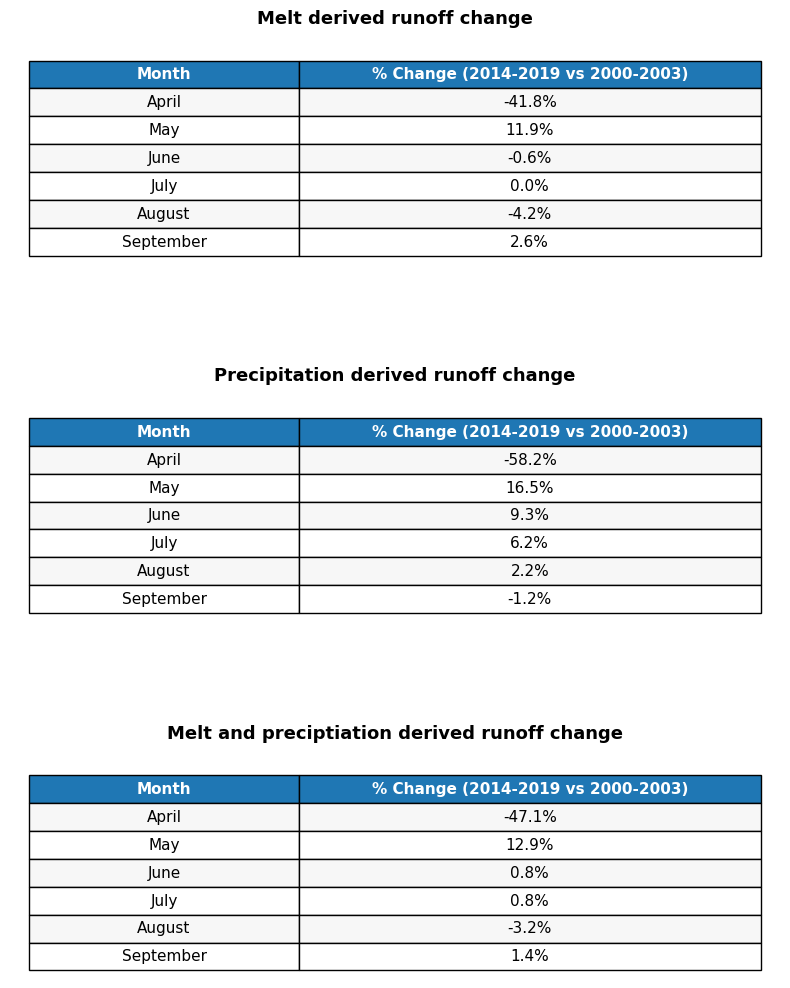

In [ ]:
# Load the dataset
ds = load_glacier_dataset(gdirs)

# Calculate 2000-2009 values relative to 2010-2019 baseline
def calculate_percentage_change(dataset, variable_name):
    # Calculate baseline (2000-2003 mean)
    baseline = dataset[variable_name].sel(time=slice('2000', '2009')).mean(dim='time')
    
    # Get recent period mean (2016-2019)
    recent = dataset[variable_name].sel(time=slice('2010', '2019')).mean(dim='time')
    
    # Calculate percentage change
    percent_change = ((recent - baseline) / baseline) * 100
    
    return percent_change

# Table creation and formatting (summer months only)
def create_percentage_table(ax, percent_change, title):
    # Assuming standard month numbering (0=Jan to 11=Dec)
    summer_months = [3, 4, 5, 6, 7, 8]  # April to September
    month_names = ['April', 'May', 'June', 'July', 'August', 'September']
    values = percent_change.values[summer_months]

    # Table data
    table_data = [
        ['Month', '% Change (2014-2019 vs 2000-2003)'],
        *[[month, f'{value:.1f}%'] for month, value in zip(month_names, values)]
    ]

    # Create table
    table = ax.table(cellText=table_data, loc='center', cellLoc='center',
                    colWidths=[0.35, 0.6])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)

    # Header styling
    for i in range(2):
        table[(0, i)].set_facecolor('#1f77b4')  # Blue header
        table[(0, i)].set_text_props(color='white', weight='bold')

    # Alternate row colors
    for row in range(1, len(table_data)):
        color = '#f7f7f7' if row % 2 == 1 else '#ffffff'
        for col in range(2):
            table[(row, col)].set_facecolor(color)

    # Add title
    ax.set_title(title, y=1.1, fontsize=13, fontweight='bold')
    ax.axis('off')

# Load data  
ds = load_glacier_dataset(gdirs)  

# Calculate changes for each component  
runoff_change = calculate_percentage_change(ds, 'melt_on_glacier_monthly')  
precip_change = calculate_percentage_change(ds, 'liq_prcp_on_glacier_monthly')  

# Calculate total runoff properly by summing components first  
total_runoff = ds['melt_on_glacier_monthly'] + ds['liq_prcp_on_glacier_monthly']  
total_runoff_monthly = total_runoff  # Assign to a new variable with a clear name  

# Create a new DataArray
ds['total_runoff_monthly'] = total_runoff_monthly  


total_change = calculate_percentage_change(ds, 'total_runoff_monthly')  

# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))

# Plot tables
create_percentage_table(ax1, runoff_change, 'Melt derived runoff change')
create_percentage_table(ax2, precip_change, 'Precipitation derived runoff change')
create_percentage_table(ax3, total_change, 'Melt and preciptiation derived runoff change')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.7)  # Space between tables

# Save output
plt.savefig('figureout/Summer_Percentage_Changes_GSWPW5E5.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()